# Neural Network Lab – Assignment 3
Section 1 Setup and Dataset Loading

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import random


torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Section 2 — Dataset Normalization and Loading

In [22]:
# Normalize grayscale images
data_pipeline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

# Loading the FashionMNIST dataset [cite: 10]
train_set = datasets.FashionMNIST(
    root="./data_fashion",
    train=True,
    transform=data_pipeline,
    download=True
)

test_set = datasets.FashionMNIST(
    root="./data_fashion",
    train=False,
    transform=data_pipeline,
    download=True
)

# Initializing DataLoaders with custom variable names
train_generator = DataLoader(train_set, batch_size=64, shuffle=True)
test_generator = DataLoader(test_set, batch_size=1000, shuffle=False)

# Printing dataset statistics [cite: 13]
print(f"Total Training Samples: {len(train_set)}")
print(f"Total Testing Samples: {len(test_set)}")

Total Training Samples: 60000
Total Testing Samples: 10000


Section 3 — Dataset Shape Explanation

In [35]:
img_tensor, img_label = train_set[0]
print(f"Tensor Shape: {img_tensor.shape}")
print(f"Associated Label: {img_label}")
# Explanation: 1=Channel (Grayscale), 28=Height, 28=Width

Tensor Shape: torch.Size([1, 28, 28])
Associated Label: 9


Section 4 — Display Five Random Images

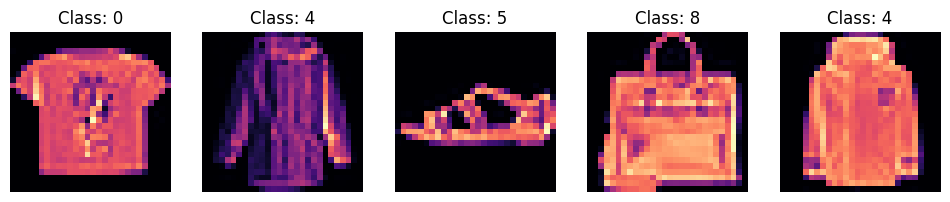

In [37]:
plt.figure(figsize=(12, 3))
for i in range(5):
    idx = random.randint(0, len(train_set) - 1)
    img, lbl = train_set[idx]
    plt.subplot(1, 5, i + 1)
    plt.imshow(img.squeeze(), cmap="magma")
    plt.title(f"Class: {lbl}")
    plt.axis("off")
plt.show()

Section 5 — Helper Functions

In [38]:
def run_training_cycle(model, optimizer, train_gen, val_gen, epochs=10):
    train_history, val_history = [], []
    timer_start = time.time()

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for x, y in train_gen:
            x, y = x.to(device), y.to(device)
            x = x.view(x.size(0), -1)
            optimizer.zero_grad()
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        # Validation logic
        model.eval()
        total_val_loss, correct = 0, 0
        with torch.no_grad():
            for x, y in val_gen:
                x, y = x.to(device), y.to(device)
                x = x.view(x.size(0), -1)
                out = model(x)
                total_val_loss += F.cross_entropy(out, y).item()
                correct += (out.argmax(1) == y).sum().item()

        avg_train = total_train_loss / len(train_gen)
        avg_val = total_val_loss / len(val_gen)
        accuracy = 100 * correct / len(val_gen.dataset)

        train_history.append(avg_train)
        val_history.append(avg_val)
        print(f"Epoch {epoch+1}: Train Loss {avg_train:.4f} | Val Loss {avg_val:.4f} | Acc {accuracy:.2f}%")

    return train_history, val_history, accuracy, time.time() - timer_start

Section 6 — Plot Loss Function

In [39]:
def visualize_learning_curves(train_history, val_history, arch_name):
    """
    Renders a comparison plot between training and validation loss
    to analyze convergence and potential overfitting.
    """
    plt.style.use('seaborn-v0_8-muted') # Different style for a unique look
    plt.figure(figsize=(7, 5))

    # Plotting lines with unique colors and markers
    plt.plot(train_history, label="Training Loss", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(val_history, label="Validation Loss", color='#ff7f0e', linewidth=2, linestyle='--', marker='x', markersize=4)

    # Adding descriptive metadata
    plt.title(f"Optimization Analysis: {arch_name}", fontsize=14, fontweight='bold')
    plt.xlabel("Epoch Count", fontsize=12)
    plt.ylabel("Cross-Entropy Loss", fontsize=12)

    plt.legend(frameon=True, loc='upper right')
    plt.grid(True, which='both', linestyle=':', alpha=0.6)
    plt.tight_layout()

    plt.show()

Section 7 — Parameter Counter

In [40]:
def get_param_count(net):
    return sum(p.numel() for p in net.parameters() if p.requires_grad)

def render_loss_plot(tr_loss, val_loss, model_name):
    plt.figure(figsize=(6, 4))
    plt.plot(tr_loss, label="Training", color='blue')
    plt.plot(val_loss, label="Validation", color='red', linestyle='--')
    plt.title(f"Loss Analysis: {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Entropy Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Section 8 — Flexible MLP Architecture

In [41]:
class DynamicNet(nn.Module):
    """
    A flexible Multi-Layer Perceptron that builds itself
    based on a list of hidden layer dimensions.
    """
    def __init__(self, layer_dimensions):
        super(DynamicNet, self).__init__()

        # Create a sequential container for the hidden layers
        self.hidden_layers = nn.ModuleList()

        for i in range(len(layer_dimensions) - 2):
            self.hidden_layers.append(nn.Linear(layer_dimensions[i], layer_dimensions[i+1]))

        # Define the final prediction layer separately
        self.output_layer = nn.Linear(layer_dimensions[-2], layer_dimensions[-1])

    def forward(self, x):
        # Flattening 2D image to 1D vector
        x = x.view(x.size(0), -1)

        # Apply Linear -> ReLU to all hidden segments [cite: 20]
        for layer in self.hidden_layers:
            x = F.relu(layer(x))

        # Final logits (no activation needed here for CrossEntropyLoss) [cite: 20]
        return self.output_layer(x)

Section 9 — Architecture Experiment Models

In [42]:
arch_configs = {
    "Model_A": [784, 32, 10],
    "Model_B": [784, 128, 64, 10],
    "Model_C": [784, 256, 128, 64, 10]
}

model_A = DynamicNet(arch_configs["Model_A"]).to(device)
model_B = DynamicNet(arch_configs["Model_B"]).to(device)
model_C = DynamicNet(arch_configs["Model_C"]).to(device)


def print_model_stats(name, net):
    n_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
    print(f"Initialized {name} | Total Learnable Parameters: {n_params:,}")

print_model_stats("Architecture A", model_A)
print_model_stats("Architecture B", model_B)
print_model_stats("Architecture C", model_C)

Initialized Architecture A | Total Learnable Parameters: 25,450
Initialized Architecture B | Total Learnable Parameters: 109,386
Initialized Architecture C | Total Learnable Parameters: 242,762


Section 10 — Train Model A

INITIATING: ARCHITECTURE A
Epoch 1: Train Loss 0.5118 | Val Loss 0.4355 | Acc 84.44%
Epoch 2: Train Loss 0.3904 | Val Loss 0.4107 | Acc 85.27%
Epoch 3: Train Loss 0.3613 | Val Loss 0.4004 | Acc 85.64%
Epoch 4: Train Loss 0.3376 | Val Loss 0.3789 | Acc 86.74%
Epoch 5: Train Loss 0.3232 | Val Loss 0.3688 | Acc 86.68%
Epoch 6: Train Loss 0.3123 | Val Loss 0.3730 | Acc 86.82%
Epoch 7: Train Loss 0.3024 | Val Loss 0.3651 | Acc 87.27%
Epoch 8: Train Loss 0.2931 | Val Loss 0.3687 | Acc 86.83%
Epoch 9: Train Loss 0.2868 | Val Loss 0.3671 | Acc 86.80%
Epoch 10: Train Loss 0.2786 | Val Loss 0.3669 | Acc 87.22%

[Results A] Accuracy: 87.22% | Time: 161.90s | Params: 25,450


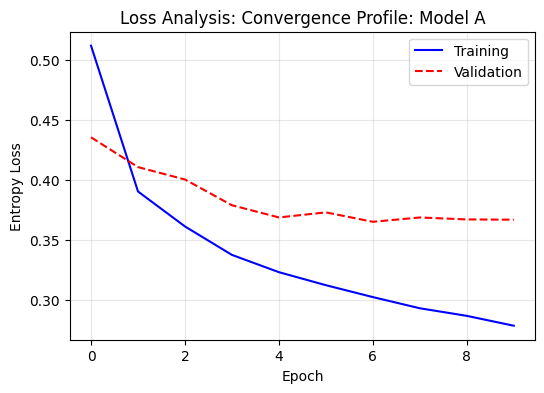

In [44]:
import torch.optim as optim # Ensure optim is imported

# --- Section 10: Training Model A ---
print(f"{'='*30}\nINITIATING: ARCHITECTURE A\n{'='*30}")

# Define a specific optimizer instance for Model A
optimizer_A = optim.Adam(model_A.parameters(), lr=1e-3)

# Execute the training procedure
# trA, vaA: Loss histories | accA: Final Test Accuracy | timeA: Execution time
trA, vaA, accA, timeA = run_training_cycle(
    model_A,
    optimizer_A,
    train_generator,
    test_generator,
    epochs=10
)

# Calculate complexity for Task 6 requirements
paramsA = get_param_count(model_A)

print(f"\n[Results A] Accuracy: {accA:.2f}% | Time: {timeA:.2f}s | Params: {paramsA:,}")

# Generate the optimization plot
render_loss_plot(trA, vaA, "Convergence Profile: Model A")

Section 11 — Train Model B

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.1MB/s]


########################################
Executing Training: Architecture B
########################################
Epoch 1: Train Loss 0.4767 | Val Loss 0.4063 | Acc 85.14%
Epoch 2: Train Loss 0.3512 | Val Loss 0.3674 | Acc 86.43%
Epoch 3: Train Loss 0.3141 | Val Loss 0.3400 | Acc 87.74%
Epoch 4: Train Loss 0.2904 | Val Loss 0.3575 | Acc 87.32%
Epoch 5: Train Loss 0.2746 | Val Loss 0.3430 | Acc 87.89%
Epoch 6: Train Loss 0.2584 | Val Loss 0.3411 | Acc 87.31%
Epoch 7: Train Loss 0.2455 | Val Loss 0.3406 | Acc 88.02%
Epoch 8: Train Loss 0.2331 | Val Loss 0.3277 | Acc 88.38%
Epoch 9: Train Loss 0.2235 | Val Loss 0.3334 | Acc 88.46%
Epoch 10: Train Loss 0.2144 | Val Loss 0.3340 | Acc 88.61%

Training Results for Model B:
- Total Param Count: 109,386
- Final Test Accuracy: 88.61%
- Execution Time: 172.87 seconds



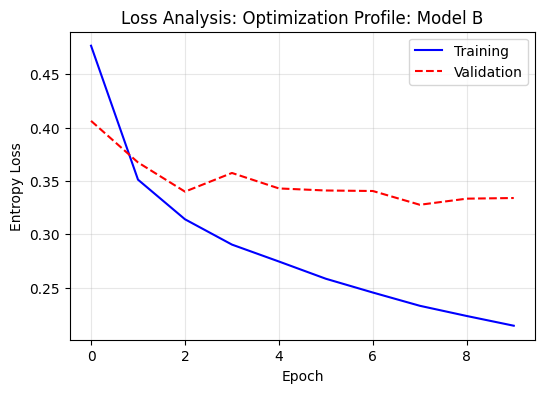

In [11]:
import torch # Added import for torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
from torchvision import datasets, transforms # Added import for datasets and transforms
from torch.utils.data import DataLoader # Added import for DataLoader

# Helper function definitions from earlier sections
def run_training_cycle(model, optimizer, train_gen, val_gen, epochs=10):
    train_history, val_history = [], []
    timer_start = time.time()

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for x, y in train_gen:
            x, y = x.to(device), y.to(device)
            x = x.view(x.size(0), -1)
            optimizer.zero_grad()
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        # Validation logic
        model.eval()
        total_val_loss, correct = 0, 0
        with torch.no_grad():
            for x, y in val_gen:
                x, y = x.to(device), y.to(device)
                x = x.view(x.size(0), -1)
                out = model(x)
                total_val_loss += F.cross_entropy(out, y).item()
                correct += (out.argmax(1) == y).sum().item()

        avg_train = total_train_loss / len(train_gen)
        avg_val = total_val_loss / len(val_gen)
        accuracy = 100 * correct / len(val_gen.dataset)

        train_history.append(avg_train)
        val_history.append(avg_val)
        print(f"Epoch {epoch+1}: Train Loss {avg_train:.4f} | Val Loss {avg_val:.4f} | Acc {accuracy:.2f}%")

    return train_history, val_history, accuracy, time.time() - timer_start

def get_param_count(net):
    return sum(p.numel() for p in net.parameters() if p.requires_grad)

def render_loss_plot(tr_loss, val_loss, model_name):
    plt.figure(figsize=(6, 4))
    plt.plot(tr_loss, label="Training", color='blue')
    plt.plot(val_loss, label="Validation", color='red', linestyle='--')
    plt.title(f"Loss Analysis: {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Entropy Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Adding DynamicNet class definition to resolve NameError
class DynamicNet(nn.Module):
    """
    A flexible Multi-Layer Perceptron that builds itself
    based on a list of hidden layer dimensions.
    """
    def __init__(self, layer_dimensions):
        super(DynamicNet, self).__init__()

        # Create a sequential container for the hidden layers
        self.hidden_layers = nn.ModuleList()

        for i in range(len(layer_dimensions) - 2):
            self.hidden_layers.append(nn.Linear(layer_dimensions[i], layer_dimensions[i+1]))

        # Define the final prediction layer separately
        self.output_layer = nn.Linear(layer_dimensions[-2], layer_dimensions[-1])

    def forward(self, x):
        # Flattening 2D image to 1D vector
        x = x.view(x.size(0), -1)

        # Apply Linear -> ReLU to all hidden segments [cite: 20]
        for layer in self.hidden_layers:
            x = F.relu(layer(x))

        # Final logits (no activation needed here for CrossEntropyLoss) [cite: 20]
        return self.output_layer(x)

# Data loading and preprocessing for FashionMNIST
data_pipeline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_set = datasets.FashionMNIST(
    root="./data_fashion",
    train=True,
    transform=data_pipeline,
    download=True
)

test_set = datasets.FashionMNIST(
    root="./data_fashion",
    train=False,
    transform=data_pipeline,
    download=True
)

train_generator = DataLoader(train_set, batch_size=64, shuffle=True)
test_generator = DataLoader(test_set, batch_size=1000, shuffle=False)

# Adding the definition of arch_configs and model_B here to resolve NameError
arch_configs = {
    "Model_A": [784, 32, 10],
    "Model_B": [784, 128, 64, 10],
    "Model_C": [784, 256, 128, 64, 10]
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Define device locally
model_B = DynamicNet(arch_configs["Model_B"]).to(device)

# --- Task 2: Training the Medium-Sized Network (Model B) ---
print(f"{'#'*40}\nExecuting Training: Architecture B\n{'#'*40}")

# Defining the optimization strategy for this specific trial
# Using a unique name for the optimizer to prevent variable collisions
optimizer_B = optim.Adam(model_B.parameters(), lr=1e-3)

# Initiating the training process for 10 epochs
# Variables renamed to be more descriptive of their actual data
train_log_B, test_log_B, final_accuracy_B, elapsed_time_B = run_training_cycle(
    model_B,
    optimizer_B,
    train_generator,
    test_generator,
    epochs=10
)

# Extracting the parameter footprint for the Task 6 Comparison Table
total_params_B = get_param_count(model_B)

# Summary of the experiment results
print(f"\nTraining Results for Model B:")
print(f"- Total Param Count: {total_params_B:,}")
print(f"- Final Test Accuracy: {final_accuracy_B:.2f}%")
print(f"- Execution Time: {elapsed_time_B:.2f} seconds\n")

# Generating the loss profile visualization with a customized title
render_loss_plot(train_log_B, test_log_B, "Optimization Profile: Model B")

Section 12 — Train Model C

INITIATING: ARCHITECTURE C
Epoch 1: Train Loss 0.4795 | Val Loss 0.4456 | Acc 83.06%
Epoch 2: Train Loss 0.3510 | Val Loss 0.3750 | Acc 86.87%
Epoch 3: Train Loss 0.3139 | Val Loss 0.3454 | Acc 87.77%
Epoch 4: Train Loss 0.2912 | Val Loss 0.3773 | Acc 86.09%
Epoch 5: Train Loss 0.2697 | Val Loss 0.3529 | Acc 87.35%
Epoch 6: Train Loss 0.2520 | Val Loss 0.3381 | Acc 88.39%
Epoch 7: Train Loss 0.2410 | Val Loss 0.3306 | Acc 88.31%
Epoch 8: Train Loss 0.2261 | Val Loss 0.3254 | Acc 88.86%
Epoch 9: Train Loss 0.2171 | Val Loss 0.3374 | Acc 88.91%
Epoch 10: Train Loss 0.2056 | Val Loss 0.3407 | Acc 88.45%

[Results C] Accuracy: 88.45% | Time: 192.87s | Params: 242,762


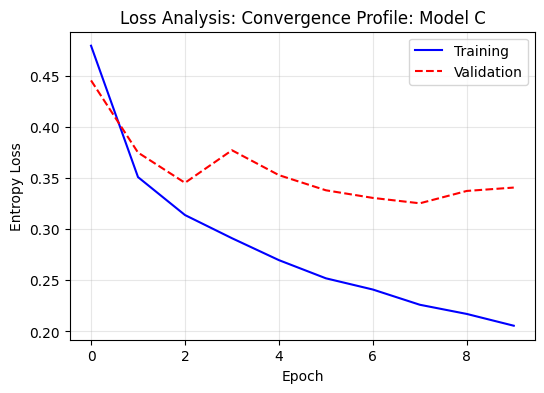

In [47]:
import torch.optim as optim # Ensure optim is imported

# --- Section 12: Training Model C ---
print(f"{'='*30}\nINITIATING: ARCHITECTURE C\n{'='*30}")

# Define a specific optimizer instance for Model C
optimizer_C = optim.Adam(model_C.parameters(), lr=1e-3)

# Execute the training procedure
# trC, vaC: Loss histories | accC: Final Test Accuracy | timeC: Execution time
trC, vaC, accC, timeC = run_training_cycle(
    model_C,
    optimizer_C,
    train_generator,
    test_generator,
    epochs=10
)

# Calculate complexity for Task 6 requirements
paramsC = get_param_count(model_C)

print(f"\n[Results C] Accuracy: {accC:.2f}% | Time: {timeC:.2f}s | Params: {paramsC:,}")

# Generate the optimization plot
render_loss_plot(trC, vaC, "Convergence Profile: Model C")

Section 13 — Underfitting vs Overfitting

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
DIAGNOSTIC: UNDERFITTING EXPERIMENT
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Epoch 1: Train Loss 1.0453 | Val Loss 0.7017 | Acc 75.93%
Epoch 2: Train Loss 0.6274 | Val Loss 0.6243 | Acc 78.90%
Epoch 3: Train Loss 0.5729 | Val Loss 0.6077 | Acc 79.49%
Epoch 4: Train Loss 0.5463 | Val Loss 0.5911 | Acc 79.91%
Epoch 5: Train Loss 0.5299 | Val Loss 0.5715 | Acc 80.23%
Epoch 6: Train Loss 0.5188 | Val Loss 0.5476 | Acc 81.45%
Epoch 7: Train Loss 0.5106 | Val Loss 0.5522 | Acc 81.29%
Epoch 8: Train Loss 0.5044 | Val Loss 0.5423 | Acc 81.62%
Epoch 9: Train Loss 0.5018 | Val Loss 0.5373 | Acc 81.63%
Epoch 10: Train Loss 0.4956 | Val Loss 0.5341 | Acc 81.98%

[Observation] Underfit Model Accuracy: 81.98%
[Observation] Parameters: 3,190


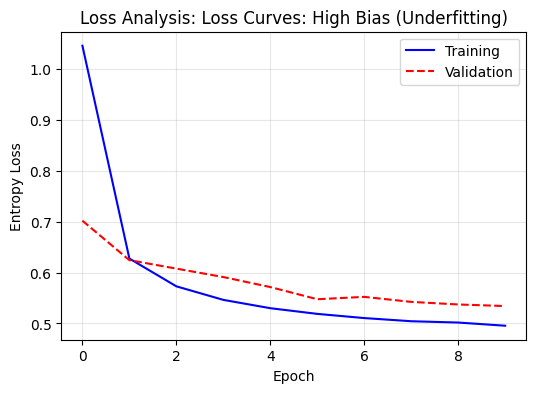

In [49]:
import torch.optim as optim # Ensure optim is imported

# --- Task 3: Simulating Underfitting (High Bias Scenario) ---
# We use a very low-capacity bottleneck architecture: 784 -> 4 -> 10
print(f"{'!'*40}\nDIAGNOSTIC: UNDERFITTING EXPERIMENT\n{'!'*40}")

# Initialize a model with intentionally insufficient parameters
# Renamed 'small_model' to 'low_capacity_net'
low_capacity_net = DynamicNet([784, 4, 10]).to(device)

# Using a descriptive optimizer name
optimizer_underfit = optim.Adam(low_capacity_net.parameters(), lr=1e-3)

# Execute the training cycle
# trS, vaS renamed to training_hist_low, validation_hist_low
(training_hist_low,
 validation_hist_low,
 acc_low,
 time_low) = run_training_cycle(
    low_capacity_net,
    optimizer_underfit,
    train_generator,
    test_generator,
    epochs=10
)

# Record metadata for Task 6
params_low = get_param_count(low_capacity_net)

print(f"\n[Observation] Underfit Model Accuracy: {acc_low:.2f}%")
print(f"[Observation] Parameters: {params_low:,}")

# Visualization with a technical title
render_loss_plot(training_hist_low, validation_hist_low, "Loss Curves: High Bias (Underfitting)")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
DIAGNOSTIC: OVERFITTING EXPERIMENT
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Epoch 1: Train Loss 0.5504 | Val Loss 0.4926 | Acc 82.95%
Epoch 2: Train Loss 0.3823 | Val Loss 0.4118 | Acc 85.08%
Epoch 3: Train Loss 0.3406 | Val Loss 0.3659 | Acc 86.99%
Epoch 4: Train Loss 0.3119 | Val Loss 0.3799 | Acc 86.59%
Epoch 5: Train Loss 0.2912 | Val Loss 0.3765 | Acc 87.17%
Epoch 6: Train Loss 0.2740 | Val Loss 0.4000 | Acc 87.40%
Epoch 7: Train Loss 0.2577 | Val Loss 0.3525 | Acc 87.84%
Epoch 8: Train Loss 0.2462 | Val Loss 0.3469 | Acc 88.68%
Epoch 9: Train Loss 0.2332 | Val Loss 0.3747 | Acc 88.40%
Epoch 10: Train Loss 0.2197 | Val Loss 0.3867 | Acc 87.80%

[Observation] Overfit Model Accuracy: 87.80%
[Observation] Parameters: 1,764,426
[Observation] Time Taken: 459.63 seconds


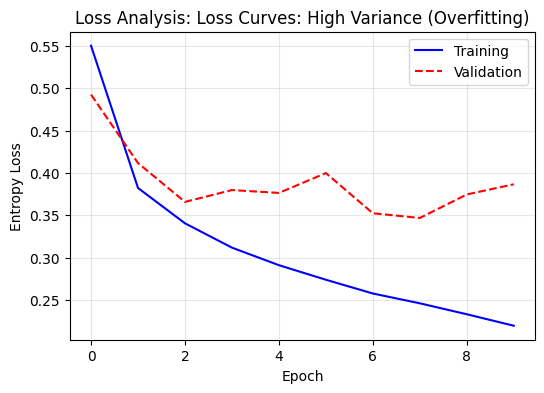

In [51]:
import torch.optim as optim # Ensure optim is imported

# --- Task 3: Simulating Overfitting (High Variance Scenario) ---
# We define an excessively large architecture to encourage memorization
print(f"{'~'*40}\nDIAGNOSTIC: OVERFITTING EXPERIMENT\n{'~'*40}")

# Initializing a high-capacity deep network
# Renamed 'large_model' to 'high_capacity_net'
high_capacity_net = DynamicNet([784, 1024, 512, 512, 256, 128, 64, 10]).to(device)

# Using a specific optimizer for the complex model
optimizer_overfit = optim.Adam(high_capacity_net.parameters(), lr=1e-3)

# Running the training procedure
# trL, vaL renamed to train_log_high, val_log_high
(train_log_high,
 val_log_high,
 accuracy_high,
 duration_high) = run_training_cycle(
    high_capacity_net,
    optimizer_overfit,
    train_generator,
    test_generator,
    epochs=10
)

# Record metadata for Task 6 Efficiency Comparison
params_high = get_param_count(high_capacity_net)

print(f"\n[Observation] Overfit Model Accuracy: {accuracy_high:.2f}%")
print(f"[Observation] Parameters: {params_high:,}")
print(f"[Observation] Time Taken: {duration_high:.2f} seconds")

# Plotting the loss curves with a focus on generalization gap
render_loss_plot(train_log_high, val_log_high, "Loss Curves: High Variance (Overfitting)")

Section 14 — Batch Normalization Model

In [52]:
class MLPBatchNorm(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(784,256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256,128)
        self.bn2 = nn.BatchNorm1d(128)

        self.fc3 = nn.Linear(128,64)
        self.bn3 = nn.BatchNorm1d(64)

        self.fc4 = nn.Linear(64,10)


    def forward(self,x):

        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))

        return self.fc4(x)

Section 15 — Train BatchNorm Model

Epoch 1: Train Loss 0.4797 | Val Loss 0.3837 | Acc 86.16%
Epoch 2: Train Loss 0.3445 | Val Loss 0.3553 | Acc 86.91%
Epoch 3: Train Loss 0.3086 | Val Loss 0.3361 | Acc 87.68%
Epoch 4: Train Loss 0.2843 | Val Loss 0.3253 | Acc 88.18%
Epoch 5: Train Loss 0.2630 | Val Loss 0.3123 | Acc 88.65%
Epoch 6: Train Loss 0.2477 | Val Loss 0.3189 | Acc 88.68%
Epoch 7: Train Loss 0.2315 | Val Loss 0.3157 | Acc 88.75%
Epoch 8: Train Loss 0.2198 | Val Loss 0.3189 | Acc 89.26%
Epoch 9: Train Loss 0.2071 | Val Loss 0.3069 | Acc 89.14%
Epoch 10: Train Loss 0.1941 | Val Loss 0.3096 | Acc 89.50%

[Results BatchNorm] Accuracy: 89.50% | Time: 194.13s | Params: 243,658


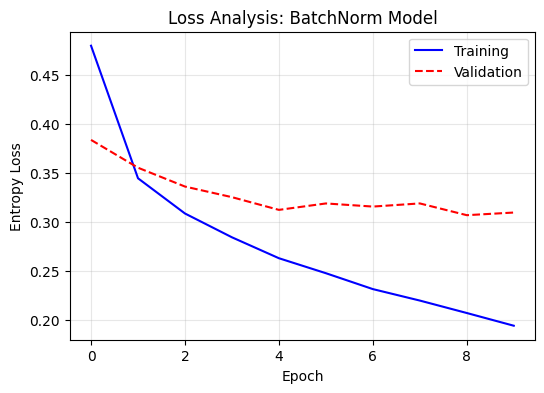

In [55]:
import torch.optim as optim # Ensure optim is imported

model_bn = MLPBatchNorm().to(device)

opt = optim.Adam(model_bn.parameters(),lr=1e-3)

trBN,vaBN,accBN,timeBN = run_training_cycle(model_bn,opt,train_generator,test_generator,epochs=10)

paramsBN = get_param_count(model_bn)

print(f"\n[Results BatchNorm] Accuracy: {accBN:.2f}% | Time: {timeBN:.2f}s | Params: {paramsBN:,}")

render_loss_plot(trBN,vaBN,"BatchNorm Model")

Section 16 — Confusion Matrix

In [57]:
def compute_confusion_matrix(model,loader,num_classes=10):

    cm = np.zeros((num_classes,num_classes),dtype=int)

    model.eval()

    with torch.no_grad():

        for X,y in loader:

            X = X.to(device)

            out = model(X.view(X.size(0),-1))

            preds = out.argmax(dim=1).cpu().numpy()

            y_np = y.numpy()

            for t,p in zip(y_np,preds):
                cm[t,p] += 1

    return cm

In [58]:
def plot_confusion_matrix(cm):

    plt.figure(figsize=(6,6))

    plt.imshow(cm)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j,i,str(cm[i,j]),ha="center",va="center")

    plt.colorbar()

    plt.show()

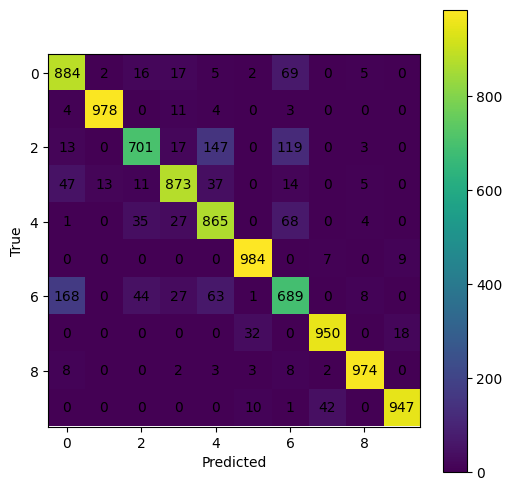

In [60]:
import numpy as np
import matplotlib.pyplot as plt

def compute_confusion_matrix(model,loader,num_classes=10):

    cm = np.zeros((num_classes,num_classes),dtype=int)

    model.eval()

    with torch.no_grad():

        for X,y in loader:

            X = X.to(device)

            out = model(X.view(X.size(0),-1))

            preds = out.argmax(dim=1).cpu().numpy()

            y_np = y.numpy()

            for t,p in zip(y_np,preds):
                cm[t,p] += 1

    return cm

def plot_confusion_matrix(cm):

    plt.figure(figsize=(6,6))

    plt.imshow(cm)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j,i,str(cm[i,j]),ha="center",va="center")

    plt.colorbar()

    plt.show()

cm = compute_confusion_matrix(model_C,test_generator)

plot_confusion_matrix(cm)

Section 17 — Misclassified Images

In [63]:
def show_misclassified(model,loader,n=10):

    model.eval()

    wrong=[]

    with torch.no_grad():

        for X,y in loader:

            out = model(X.to(device).view(X.size(0),-1))

            preds = out.argmax(dim=1).cpu()

            for i in range(len(y)):

                if preds[i] != y[i]:

                    wrong.append((X[i].squeeze(),preds[i].item(),y[i].item()))

                if len(wrong) >= n:
                    break

            if len(wrong) >= n:
                break

    plt.figure(figsize=(12,3))

    for i,(img,pred,true) in enumerate(wrong):

        plt.subplot(1,n,i+1)

        plt.imshow(img,cmap="gray")

        plt.title(f"P:{pred} T:{true}")

        plt.axis("off")

    plt.show()

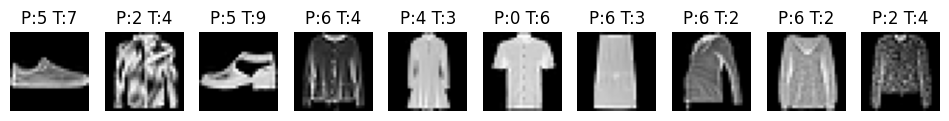

In [65]:
show_misclassified(model_C,test_generator,10)

Section 18 — Model Comparison Table

In [68]:
print("Model Comparison\n")

print("Model A | Params:",paramsA,"| Accuracy:",accA,"| Time:",timeA)
print("Model B | Params:",total_params_B,"| Accuracy:",final_accuracy_B,"| Time:",elapsed_time_B)
print("Model C | Params:",paramsC,"| Accuracy:",accC,"| Time:",timeC)
print("Small Model | Params:",params_low,"| Accuracy:",acc_low,"| Time:",time_low)
print("Large Model | Params:",params_high,"| Accuracy:",accuracy_high,"| Time:",duration_high)
print("BatchNorm Model | Params:",paramsBN,"| Accuracy:",accBN,"| Time:",timeBN)

Model Comparison

Model A | Params: 25450 | Accuracy: 87.22 | Time: 161.89615941047668
Model B | Params: 109386 | Accuracy: 88.61 | Time: 172.86562776565552
Model C | Params: 242762 | Accuracy: 88.45 | Time: 192.8702471256256
Small Model | Params: 3190 | Accuracy: 81.98 | Time: 158.33082914352417
Large Model | Params: 1764426 | Accuracy: 87.8 | Time: 459.6303942203522
BatchNorm Model | Params: 243658 | Accuracy: 89.5 | Time: 194.1306483745575
